# Sequence Processing with HMMs and CRFs

**The goal of this practical is to study sequence models in NLP.**

We will work on Part-Of-Speech (POS) and optionally on chunking (gathering different groups in sentences). The datasets are from [CONLL 2000](https://www.clips.uantwerpen.be/conll2000/chunking/): 
- **Small corpus:** chtrain/chtest to understand the tools and models 
- **Larger corpus:** train/test to collect reliable experimental results


# 1) HMMS


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading POS/Chunking data
def load(filename):
    listeDoc = list()
    with open(filename, "r") as f:
        doc = list()
        for ligne in f:
            if len(ligne) < 2: # fin de doc
                listeDoc.append(doc)
                doc = list()
                continue
            mots = ligne.replace("\n","").split(" ")
            doc.append((mots[0],mots[1])) # Change mots[1] -> mots[2] for chuncking
    return listeDoc

In [3]:
# =============== loding ============
# small corpus => ideal for first tests
filename = "./conll2000/conll2000/chtrain.txt" 
filenameT = "./conll2000/conll2000/chtest.txt" 

# Larger corpus => To valide perf.
# filename = "./conll2000/conll2000/train.txt" 
# filenameT = "./conll2000/conll2000/test.txt" 

alldocs = load(filename)
alldocsT = load(filenameT)

print(len(alldocs)," docs read")
print(len(alldocsT)," docs (T) read")

823  docs read
77  docs (T) read


In [4]:
print(alldocs[0])
print(alldocsT[0])

[('Rockwell', 'NNP'), ('International', 'NNP'), ('Corp.', 'NNP'), ("'s", 'POS'), ('Tulsa', 'NNP'), ('unit', 'NN'), ('said', 'VBD'), ('it', 'PRP'), ('signed', 'VBD'), ('a', 'DT'), ('tentative', 'JJ'), ('agreement', 'NN'), ('extending', 'VBG'), ('its', 'PRP$'), ('contract', 'NN'), ('with', 'IN'), ('Boeing', 'NNP'), ('Co.', 'NNP'), ('to', 'TO'), ('provide', 'VB'), ('structural', 'JJ'), ('parts', 'NNS'), ('for', 'IN'), ('Boeing', 'NNP'), ("'s", 'POS'), ('747', 'CD'), ('jetliners', 'NNS'), ('.', '.')]
[('Confidence', 'NN'), ('in', 'IN'), ('the', 'DT'), ('pound', 'NN'), ('is', 'VBZ'), ('widely', 'RB'), ('expected', 'VBN'), ('to', 'TO'), ('take', 'VB'), ('another', 'DT'), ('sharp', 'JJ'), ('dive', 'NN'), ('if', 'IN'), ('trade', 'NN'), ('figures', 'NNS'), ('for', 'IN'), ('September', 'NNP'), (',', ','), ('due', 'JJ'), ('for', 'IN'), ('release', 'NN'), ('tomorrow', 'NN'), (',', ','), ('fail', 'VB'), ('to', 'TO'), ('show', 'VB'), ('a', 'DT'), ('substantial', 'JJ'), ('improvement', 'NN'), ('from'

## Building a baseline POS model (without sequence)

We will build a simple dictionary ```word => PoS label``` without taking into account any sequence information. We will compare the sequence models to this baseline.

The dataset is a list a tuples with ```(word, POS)```. **Build a simple dictionary mapping each word to its PoS tag in the train set**

In [5]:
# Dictionary building 
dico = dict()

# train set
for doc in alldocs:
  for word, tag in doc:
     dico[word] = tag

**Note: on the test set, there are unknown words...**. We will use the following simple strategy: 
```
# remplace
dico[cle] # crashing with an unknown key 
# by 
dico.get(cle, DefaultValue)
```
From a linguistic point of view, we can choose the default value as the majority PoS class, producing a stronger baseline.

In [6]:
# Evaluate test performances

# majority class
tags, counts = np.unique(list(dico.values()), return_counts = True)
maj_pos = tags[np.argmax(counts)]
print(maj_pos)

correct = 0
total = 0

for doc in alldocsT:
  for word, tag in doc:
    if dico.get(word, maj_pos) == tag:
        correct += 1  
    total += 1


NN


In [7]:
print("Accuracy ", correct/total), correct, total 

Accuracy  0.805379746835443


(None, 1527, 1896)

Check: 1433 good predictions in test over 1896

(1527 with 'NN' as default PoS value)

## HMMs

Here is a code for training HMM parameters and running decoding using the Viterbi algorithm. You should apply it to our PoS task. **N.B.: you should undersand the ```eps``` parmaters**.


In [8]:
# séquence la plus likely des états cachés 

# allx: list of observation sequences 
# allq: list os state sequences 
# N: nb states
# K: nb observations

# here N = keys, tags, K = obs, words 

def learnHMM(allx, allq, N, K, initTo1=True):
    if initTo1:
        eps = 1e-1 # You can play with this regularization parameter 
        A = np.ones((N,N))*eps
        B = np.ones((N,K))*eps
        Pi = np.ones(N)*eps
    else:
        A = np.zeros((N,N))
        B = np.zeros((N,K))
        Pi = np.zeros(N)
    for x,q in zip(allx,allq):
        Pi[int(q[0])] += 1
        for i in range(len(q)-1):
            A[int(q[i]),int(q[i+1])] += 1
            B[int(q[i]),int(x[i])] += 1
        B[int(q[-1]),int(x[-1])] += 1 # last transition
    A = A/np.maximum(A.sum(1).reshape(N,1),1) # normalisation
    B = B/np.maximum(B.sum(1).reshape(N,1),1) # normalisation
    Pi = Pi/Pi.sum()
    return Pi , A, B

def viterbi(x,Pi,A,B):
    T = len(x)
    N = len(Pi)
    logA = np.log(A)
    logB = np.log(B)
    logdelta = np.zeros((N,T))
    psi = np.zeros((N,T), dtype=int)
    S = np.zeros(T)
    logdelta[:,0] = np.log(Pi) + logB[:,int(x[0])]
    #forward
    for t in range(1,T):
        logdelta[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).max(0) + logB[:,int(x[t])]
        psi[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).argmax(0)
    # backward
    logp = logdelta[:,-1].max()
    S[T-1] = logdelta[:,-1].argmax()
    for i in range(2,T+1):
        S[int(T-i)] = psi[int(S[int(T-i+1)]),int(T-i+1)]
    return S, logp #, delta, psi
 

### Data encoding

We will map each word to an index for traing the HMM (see code below):
```
 The cat is in the garden => 1 2 3 4 1 5
```
We have to understand the dictionary functionning to retrieve the words corresponding to indices.

In [9]:
# alldocs etant issu du chargement des données
# la mise en forme des données est fournie ici
# afin de produire des analyses qualitative, vous devez malgré tout comprendre le fonctionnement des dictionnaires

buf = [[m for m,pos in d ] for d in alldocs] # only word
mots = []
[mots.extend(b) for b in buf] # flatten
mots = np.unique(np.array(mots))
nMots = len(mots)+1 # mot inconnu

mots2ind = dict(zip(mots,range(len(mots)))) # words + number
mots2ind["UUUUUUUU"] = len(mots) # mot inconnu

buf2 = [[pos for m,pos in d ] for d in alldocs] # same with pos
cles = []
[cles.extend(b) for b in buf2]
cles = np.unique(np.array(cles))
cles2ind = dict(zip(cles,range(len(cles))))

nCles = len(cles)

print(nMots,nCles," in the dictionary")

# mise en forme des données
allx  = [[mots2ind[m] for m,pos in d] for d in alldocs] # only word test train
allxT = [[mots2ind.setdefault(m,len(mots)) for m,pos in d] for d in alldocsT]

allq  = [[cles2ind[pos] for m,pos in d] for d in alldocs] # only pos test train
allqT = [[cles2ind.setdefault(pos,len(cles)) for m,pos in d] for d in alldocsT]

4570 42  in the dictionary


In [10]:
# First doc:
print(allx[0])
print(allq[0])

[1140, 814, 563, 11, 1294, 4393, 3855, 2854, 3992, 1362, 4242, 1452, 2395, 2855, 1990, 4529, 446, 525, 4299, 3595, 4148, 3368, 2499, 446, 11, 283, 2861, 20]
[18, 18, 18, 22, 18, 17, 32, 23, 32, 9, 13, 17, 33, 24, 17, 12, 18, 18, 29, 31, 13, 20, 12, 18, 22, 8, 20, 5]


In [11]:
len(mots), len(cles)

(4569, 42)

## You turn: apply HMMs to those data!

In [12]:
# HMM training 
# Pi, a, b = learnHMM(allx, allq, nMots, nCles)
Pi, a, b = learnHMM(allx, allq, nCles, nMots)

In [13]:
# HMM decoding and performances evaluation
seq, logp = viterbi(allxT[0], Pi, a, b)
seq, logp 

(array([41., 12.,  9., 17., 36., 25., 34., 29., 31.,  9., 13., 20., 12.,
        17., 20., 12., 18.,  4., 13., 12.,  9., 17.,  4., 33., 29., 31.,
         9., 13., 17., 12., 18.,  7., 18., 22., 13., 20.,  5.]),
 -260.0537140528326)

In [32]:
conf_mat = np.zeros((nCles, nCles), dtype=int)
# x = correct, y = predicted 

accuracy = 0.
correct_pred_tag = 0 

for t, k in zip(allxT, allqT):
    seq, logp = viterbi(t, Pi, a, b)
    pred_corr = np.sum((seq == k)*1.)
    accuracy += pred_corr / len(seq) # % correct dans la phrase
    correct_pred_tag += pred_corr # nombre de mots correct
    
    for i in range(len(seq)):
        conf_mat[int(k[i])-1,int(seq[i])] += 1

In [33]:
print("Accuracy ",accuracy / len(allxT))
print("Correct predictions ", correct_pred_tag)

Accuracy  0.8136518680878979
Correct predictions  1565.0


Check : 1564 in test

### Qualitative Analyis:

- With imshow on the parameters (ou d'un argsort), show what are the probable transition between labels.
- Visualize the confusion matrices to understand what is challenging in this task
- Find out examples that are corrected by Viterbi decoding



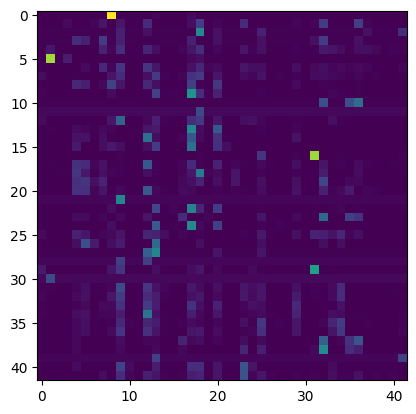

In [34]:
# transition matrix A
plt.imshow(a) 

In [35]:
# tags most probable in first
print("Most probable first tag", cles[np.argmax(Pi)] )

# transitions between labels

trans_a = np.argsort(a)
for i in range(trans_a.shape[0]):
    print(cles[i], cles[trans_a[i][-1]]) # mot le plus haut

Most probable first tag NNP
$ CD
'' NNP
( NNP
) CC
, NNP
. ''
: DT
CC NNP
CD CD
DT NN
EX VBZ
FW NNP
IN DT
JJ NN
JJR IN
JJS NN
MD VB
NN IN
NNP NNP
NNPS VBD
NNS IN
PDT DT
POS NN
PRP VBD
PRP$ NN
RB VBN
RBR JJ
RBS JJ
RP DT
TO VB
UH ''
VB DT
VBD DT
VBG IN
VBN IN
VBP VBN
VBZ VBN
WDT VBD
WP VBD
WP$ ``
WRB PRP
`` PRP


Text(0.5, 1.0, 'confusion matrix')

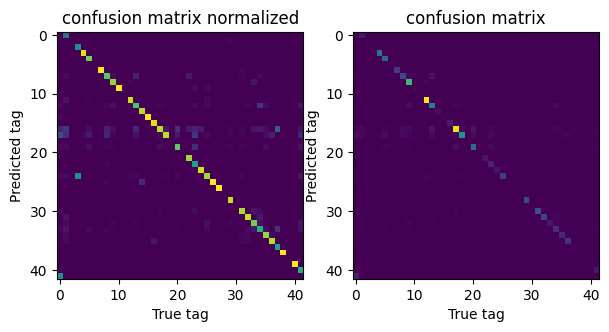

In [36]:
# confusion matrix
# normalisation

fig, axes = plt.subplots(1, 2, figsize = (7, 5))

conf_mat_norm = conf_mat / (np.sum(conf_mat, axis = 0) + 1e-5)
axes[0].imshow(conf_mat_norm)
axes[0].set_xlabel('True tag')
axes[0].set_ylabel('Predicted tag')
axes[0].set_title("confusion matrix normalized")

axes[1].imshow(conf_mat)
axes[1].set_xlabel('True tag')
axes[1].set_ylabel('Predicted tag')
axes[1].set_title("confusion matrix")

# 2) Conditional Random Fields (CRF)

**CRF are disciminative models** representing the conditional distribution $$(\mathbf{y} | \mathbf{x} , \mathbf{w})$$:




$$
P(\mathbf{y} \mid \mathbf{x}, \mathbf{w})
=
\frac{\exp\!\left(\mathbf{w}^T \psi(\mathbf{x}, \mathbf{y})\right)}
{\sum\limits_{y' \in \mathcal{Y}} \exp\!\left(\mathbf{w}^T \psi(\mathbf{x}, \mathbf{y}')\right)}
$$



**In 'linear-chain' CRFs**, the feature functions include **unary terms $u_k$** ($\sim$ $\mathbf{B}$ matrix in HMMs) and **pairwise terms $p_k$** ($\sim$ $\mathbf{A}$ matrix in HMMs):

$$ \mathbf{w}^T \psi(\mathbf{x},\mathbf{y}) = \sum\limits_{t=1}^T \sum_{k=1}^K F_k(y_{t-1}, y_t, \mathbf{x})  =   \sum\limits_{t=1}^T \sum_{k=1}^K \left[ u_k(y_t, \mathbf{x}) + p_k(y_{t-1}, y_t, \mathbf{x}) \right]$$

[<img src="https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png" width="800" >](https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png)
        

We can directly use resources from nltk: 
- [CRFTagger](https://tedboy.github.io/nlps/generated/generated/nltk.CRFTagger.html)
- [PerceptronTagger](https://www.nltk.org/_modules/nltk/tag/perceptron.html)

In [37]:
# !pip install python-crfsuite
from nltk.tag.crf import CRFTagger
tagger = CRFTagger()
tagger.train(alldocs, 'out/crf.model') # training
tagger.accuracy(alldocsT)

0.9071729957805907

In [39]:
accuracy = 0
correct = 0

for d in alldocsT:
	words = []
	tags = []
	for w, k in d:
		words.append(w)
		tags.append(k)

	preds = tagger.tag(words)
	pred_tags = np.array([k for w, k in preds])
	corr = np.sum((pred_tags == np.array(tags))*1)
	correct += corr
	accuracy += corr / len(d) # moyenne des accuracy dans les docs

accuracy/len(alldocsT), correct

(0.9038335777964042, 1720)

### Training and evaluating the model, as before

Check: 1720 bonnes réponses

In [44]:
# perceptron
from nltk.tag.perceptron    import PerceptronTagger
tagger = PerceptronTagger(load=False)
tagger.train(alldocs)
tagger.accuracy(alldocsT)

0.9229957805907173

In [45]:
accuracy = 0
correct = 0

for d in alldocsT:
	words = []
	tags = []
	for w, k in d:
		words.append(w)
		tags.append(k)

	preds = tagger.tag(words)
	pred_tags = np.array([k for w, k in preds])
	corr = np.sum((pred_tags == np.array(tags))*1)
	correct += corr
	accuracy += corr / len(d) # moyenne des accuracy dans les docs

accuracy/len(alldocsT), correct

(0.9211721938074113, 1750)

Check: 1737 bonnes réponses

# Going further

- We test the application for PoS, we can run similar experiments for chunking (see parsing indication, very simple to load data)
- Run  experiement on the larger dataset. This dataset is still largely used in research. This work can thus be included in your resume :)
- Work will be purshed with word embeddings (next practical), and for [NER](https://www.clips.uantwerpen.be/conll2003/ner/) with RNNs (X. Tannier)
- [State-of-the-art resources](https://github.com/stanfordnlp/stanza/)